<a href="https://colab.research.google.com/github/KabiruLeedsBeckett/ExampleTest/blob/master/coen807_project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ==========================================
# COEN807 TERM PROJECT
# Renewable Energy Adoption Analysis
# ==========================================

Import Libraries

In [1]:
# ==========================================
# COEN807 Renewable Energy Adoption Project
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

Upload Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Renewable_Energy_Adoption.csv to Renewable_Energy_Adoption.csv


Load Dataset

In [3]:
df = pd.read_csv("Renewable_Energy_Adoption.csv")

print("Dataset Shape:")
print(df.shape)

df.head()

Dataset Shape:
(1000, 11)


,Solar_Exposure,Wind_Speed,Government_Subsidy,Electricity_Price,Population_Density,Urbanization_Rate,Household_Income,Awareness_Programs,Grid_Accessibility,Region,Adoption_Status
0,4.990195,7.198691,16293.492568,0.415383,1841.837272,84.112213,76276.855922,High,Moderate,Urban,High
1,4.176822,5.855363,17723.248249,0.469397,1989.559324,36.893507,46921.147736,Medium,Easy,Suburban,Medium
2,5.521563,4.291278,2276.264009,0.290214,375.543290,80.440808,78001.659422,Low,Easy,Suburban,Medium
3,4.954507,11.202639,17326.760054,0.415481,327.138193,74.025158,95933.475974,High,Moderate,Urban,Medium
4,5.408639,3.438064,15993.874855,0.248384,1406.014477,65.638500,82241.480571,High,Moderate,Suburban,Low


### Full Preprocessing Steps (Reloaded and Corrected)

In [31]:
# Reload the dataset to ensure a fresh start
df = pd.read_csv("Renewable_Energy_Adoption.csv")

print("Dataset Shape after reload:")
print(df.shape)

print("\nMissing Values after reload:")
print(df.isnull().sum())

print("\nFirst Five Rows after reload:")
display(df.head())

# Handle Missing Values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("\nMissing Values after handling:")
print(df.isnull().sum())

# Clean Text Variables
object_cols = df.select_dtypes(include="object").columns
for col in object_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print("\nUnique values after cleaning:")
for col in object_cols:
    print(f"{col}: {df[col].unique()}")

# One-Hot Encode Region
df = pd.get_dummies(df, columns=["Region"], drop_first=True)

print("\nDataFrame head after One-Hot Encoding Region:")
display(df.head())

# Encode Target Variable
label_encoder = LabelEncoder()
df["Adoption_Status"] = label_encoder.fit_transform(df["Adoption_Status"])
print("\nLabelEncoder classes for Adoption_Status:", label_encoder.classes_)

# Encode 'Awareness_Programs' and 'Grid_Accessibility' correctly
awareness_program_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Awareness_Programs'] = df['Awareness_Programs'].map(awareness_program_mapping)

grid_accessibility_mapping = {'Difficult': 0, 'Moderate': 1, 'Easy': 2}
df['Grid_Accessibility'] = df['Grid_Accessibility'].map(grid_accessibility_mapping)

# Feature Engineering
df["Energy_Affordability_Index"] = df["Household_Income"] / (df["Electricity_Price"] + 1)
df["Renewable_Potential"] = df["Solar_Exposure"] + df["Wind_Speed"]
df["Infrastructure_Readiness"] = df["Urbanization_Rate"] + df["Grid_Accessibility"]
df["Policy_Awareness_Interaction"] = df["Government_Subsidy"] * df["Awareness_Programs"]

print("\nDataFrame head after Feature Engineering:")
display(df.head())

# Final Missing Value Check and Drop (should be minimal now)
print("\nMissing Values before final dropna:")
print(df.isnull().sum())
df = df.dropna()
print("\nDataset Shape after final dropna:")
print(df.shape)

# Split Features and Target
X = df.drop("Adoption_Status", axis=1)
y = df["Adoption_Status"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nNaN Values in X_scaled:", np.isnan(X_scaled).sum().sum())
print("Infinite Values in X_scaled:", np.isinf(X_scaled).sum().sum())
print("\nX_scaled head:")
display(X_scaled.head())

Dataset Shape after reload:
(1000, 11)

Missing Values after reload:
Solar_Exposure        0
Wind_Speed            0
Government_Subsidy    0
Electricity_Price     0
Population_Density    0
Urbanization_Rate     0
Household_Income      0
Awareness_Programs    0
Grid_Accessibility    0
Region                0
Adoption_Status       0
dtype: int64

First Five Rows after reload:


,Solar_Exposure,Wind_Speed,Government_Subsidy,Electricity_Price,Population_Density,Urbanization_Rate,Household_Income,Awareness_Programs,Grid_Accessibility,Region,Adoption_Status
0,4.990195,7.198691,16293.492568,0.415383,1841.837272,84.112213,76276.855922,High,Moderate,Urban,High
1,4.176822,5.855363,17723.248249,0.469397,1989.559324,36.893507,46921.147736,Medium,Easy,Suburban,Medium
2,5.521563,4.291278,2276.264009,0.290214,375.543290,80.440808,78001.659422,Low,Easy,Suburban,Medium
3,4.954507,11.202639,17326.760054,0.415481,327.138193,74.025158,95933.475974,High,Moderate,Urban,Medium
4,5.408639,3.438064,15993.874855,0.248384,1406.014477,65.638500,82241.480571,High,Moderate,Suburban,Low



Missing Values after handling:
Solar_Exposure        0
Wind_Speed            0
Government_Subsidy    0
Electricity_Price     0
Population_Density    0
Urbanization_Rate     0
Household_Income      0
Awareness_Programs    0
Grid_Accessibility    0
Region                0
Adoption_Status       0
dtype: int64

Unique values after cleaning:
Awareness_Programs: ['High' 'Medium' 'Low']
Grid_Accessibility: ['Moderate' 'Easy' 'Difficult']
Region: ['Urban' 'Suburban' 'Rural']
Adoption_Status: ['High' 'Medium' 'Low']

DataFrame head after One-Hot Encoding Region:


,Solar_Exposure,Wind_Speed,Government_Subsidy,Electricity_Price,Population_Density,Urbanization_Rate,Household_Income,Awareness_Programs,Grid_Accessibility,Adoption_Status,Region_Suburban,Region_Urban
0,4.990195,7.198691,16293.492568,0.415383,1841.837272,84.112213,76276.855922,High,Moderate,High,False,True
1,4.176822,5.855363,17723.248249,0.469397,1989.559324,36.893507,46921.147736,Medium,Easy,Medium,True,False
2,5.521563,4.291278,2276.264009,0.290214,375.543290,80.440808,78001.659422,Low,Easy,Medium,True,False
3,4.954507,11.202639,17326.760054,0.415481,327.138193,74.025158,95933.475974,High,Moderate,Medium,False,True
4,5.408639,3.438064,15993.874855,0.248384,1406.014477,65.638500,82241.480571,High,Moderate,Low,True,False



LabelEncoder classes for Adoption_Status: ['High' 'Low' 'Medium']

DataFrame head after Feature Engineering:


,Solar_Exposure,Wind_Speed,Government_Subsidy,Electricity_Price,Population_Density,Urbanization_Rate,Household_Income,Awareness_Programs,Grid_Accessibility,Adoption_Status,Region_Suburban,Region_Urban,Energy_Affordability_Index,Renewable_Potential,Infrastructure_Readiness,Policy_Awareness_Interaction
0,4.990195,7.198691,16293.492568,0.415383,1841.837272,84.112213,76276.855922,2,1,0,False,True,53891.303629,12.188887,85.112213,32586.985136
1,4.176822,5.855363,17723.248249,0.469397,1989.559324,36.893507,46921.147736,1,2,2,True,False,31932.238131,10.032185,38.893507,17723.248249
2,5.521563,4.291278,2276.264009,0.290214,375.543290,80.440808,78001.659422,0,2,2,True,False,60456.376783,9.812842,82.440808,0.000000
3,4.954507,11.202639,17326.760054,0.415481,327.138193,74.025158,95933.475974,2,1,2,False,True,67774.474299,16.157146,75.025158,34653.520108
4,5.408639,3.438064,15993.874855,0.248384,1406.014477,65.638500,82241.480571,2,1,1,True,False,65878.326988,8.846703,66.638500,31987.749709



Missing Values before final dropna:
Solar_Exposure                  0
Wind_Speed                      0
Government_Subsidy              0
Electricity_Price               0
Population_Density              0
Urbanization_Rate               0
Household_Income                0
Awareness_Programs              0
Grid_Accessibility              0
Adoption_Status                 0
Region_Suburban                 0
Region_Urban                    0
Energy_Affordability_Index      0
Renewable_Potential             0
Infrastructure_Readiness        0
Policy_Awareness_Interaction    0
dtype: int64

Dataset Shape after final dropna:
(1000, 16)

NaN Values in X_scaled: 0
Infinite Values in X_scaled: 0

X_scaled head:


,Solar_Exposure,Wind_Speed,Government_Subsidy,Electricity_Price,Population_Density,Urbanization_Rate,Household_Income,Awareness_Programs,Grid_Accessibility,Region_Suburban,Region_Urban,Energy_Affordability_Index,Renewable_Potential,Infrastructure_Readiness,Policy_Awareness_Interaction
0,0.876743,-0.114663,1.092205,0.940248,1.442094,1.369415,0.705959,1.278424,-0.031875,-0.695471,1.527525,0.411706,0.262962,1.366476,2.033315
1,0.174799,-0.637085,1.357351,1.405217,1.703696,-1.329174,-0.568397,0.044424,1.194105,1.437875,-0.654654,-0.784314,-0.523538,-1.272157,0.677415
2,1.335315,-1.245359,-1.507274,-0.137249,-1.154576,1.159591,0.780834,-1.189576,1.194105,1.437875,-0.654654,0.769279,-0.603528,1.213965,-0.939335
3,0.845943,1.442476,1.283823,0.941088,-1.240297,0.792931,1.559270,1.278424,-0.031875,-0.695471,1.527525,1.167865,1.710097,0.790605,2.221828
4,1.237861,-1.577175,1.036641,-0.497329,0.670293,0.313627,0.964888,1.278424,-0.031875,1.437875,-0.654654,1.064590,-0.955857,0.311809,1.978651


### Inspect Dataset (Re-run)

In [32]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nFirst Five Rows")
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Solar_Exposure                1000 non-null   float64
 1   Wind_Speed                    1000 non-null   float64
 2   Government_Subsidy            1000 non-null   float64
 3   Electricity_Price             1000 non-null   float64
 4   Population_Density            1000 non-null   float64
 5   Urbanization_Rate             1000 non-null   float64
 6   Household_Income              1000 non-null   float64
 7   Awareness_Programs            1000 non-null   int64  
 8   Grid_Accessibility            1000 non-null   int64  
 9   Adoption_Status               1000 non-null   int64  
 10  Region_Suburban               1000 non-null   bool   
 11  Region_Urban                  1000 non-null   bool   
 12  Energy_Affordability_Index    1000 non-null   float64
 13  Rene

,Solar_Exposure,Wind_Speed,Government_Subsidy,Electricity_Price,Population_Density,Urbanization_Rate,Household_Income,Awareness_Programs,Grid_Accessibility,Adoption_Status,Region_Suburban,Region_Urban,Energy_Affordability_Index,Renewable_Potential,Infrastructure_Readiness,Policy_Awareness_Interaction
0,4.990195,7.198691,16293.492568,0.415383,1841.837272,84.112213,76276.855922,2,1,0,False,True,53891.303629,12.188887,85.112213,32586.985136
1,4.176822,5.855363,17723.248249,0.469397,1989.559324,36.893507,46921.147736,1,2,2,True,False,31932.238131,10.032185,38.893507,17723.248249
2,5.521563,4.291278,2276.264009,0.290214,375.543290,80.440808,78001.659422,0,2,2,True,False,60456.376783,9.812842,82.440808,0.000000
3,4.954507,11.202639,17326.760054,0.415481,327.138193,74.025158,95933.475974,2,1,2,False,True,67774.474299,16.157146,75.025158,34653.520108
4,5.408639,3.438064,15993.874855,0.248384,1406.014477,65.638500,82241.480571,2,1,1,True,False,65878.326988,8.846703,66.638500,31987.749709


### View Unique Values (Re-run)

In [33]:
for col in df.columns:
    print("\n", col)
    print(df[col].unique())


 Solar_Exposure
[4.99019548 4.17682222 5.52156337 4.95450664 5.40863882 3.64286417
 5.25574023 3.66915082 3.73527596 5.71879171 3.0211908  4.7795774
 5.89774982 5.61411205 2.86792823 2.14914207 2.20794951 5.16732276
 5.982921   4.49333685 5.55647737 4.30700315 2.57883842 3.12265149
 3.85545596 5.3349781  3.32465858 4.95520986 5.11818741 3.64780975
 4.22694811 3.15641661 5.80905066 5.57323517 3.11880878 4.97829305
 5.84066611 3.77252413 5.02371723 5.96735116 4.00641711 2.5665485
 2.7566008  2.30423843 4.01270736 2.70376236 2.72668505 2.53530346
 2.31671972 4.13938126 4.72661105 2.83681495 5.5402339  2.00157305
 4.39282123 5.50916013 5.07721337 3.39734742 3.80456043 5.32523816
 5.04630889 4.50529892 4.73476452 2.04071569 5.15083324 2.43811718
 2.00485524 4.0655956  2.45611265 3.94495352 3.35486285 2.10999523
 4.23769072 3.29745433 2.18510666 2.77109866 5.45781379 5.16332929
 5.79363952 3.50304771 4.18545694 4.50386048 5.19673527 2.44856023
 3.99648202 4.31694915 2.24644836 2.42128613 2.

### Handle Missing Values (Re-run)

In [34]:
for col in df.columns:

    if df[col].dtype == "object":

        df[col] = df[col].fillna(
            df[col].mode()[0]
        )

    else:

        df[col] = df[col].fillna(
            df[col].median()
        )

print(df.isnull().sum())

Solar_Exposure                  0
Wind_Speed                      0
Government_Subsidy              0
Electricity_Price               0
Population_Density              0
Urbanization_Rate               0
Household_Income                0
Awareness_Programs              0
Grid_Accessibility              0
Adoption_Status                 0
Region_Suburban                 0
Region_Urban                    0
Energy_Affordability_Index      0
Renewable_Potential             0
Infrastructure_Readiness        0
Policy_Awareness_Interaction    0
dtype: int64


### Clean Text Variables (Re-run)

In [35]:
object_cols = df.select_dtypes(
    include="object"
).columns

for col in object_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

### Encode Target Variable (Re-run)

In [38]:
label_encoder = LabelEncoder()

df["Adoption_Status"] = (
    label_encoder.fit_transform(
        df["Adoption_Status"]
    )
)

print(label_encoder.classes_)

[0 1 2]


### Feature Engineering (Re-run with fixed encoding)

In [39]:
awareness_program_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Awareness_Programs'] = df['Awareness_Programs'].map(awareness_program_mapping)

grid_accessibility_mapping = {'Difficult': 0, 'Moderate': 1, 'Easy': 2}
df['Grid_Accessibility'] = df['Grid_Accessibility'].map(grid_accessibility_mapping)

df["Energy_Affordability_Index"] = (

    df["Household_Income"]

    /

    (df["Electricity_Price"] + 1)

)

df["Renewable_Potential"] = (

    df["Solar_Exposure"]

    +

    df["Wind_Speed"]

)

df["Infrastructure_Readiness"] = (

    df["Urbanization_Rate"]

    +

    df["Grid_Accessibility"]

)

df["Policy_Awareness_Interaction"] = (

    df["Government_Subsidy"]

    *

    df["Awareness_Programs"]

)

### Final Missing Value Check (Re-run)

In [40]:
print(df.isnull().sum())

df = df.dropna()

print("Dataset Shape:")
print(df.shape)

Solar_Exposure                     0
Wind_Speed                         0
Government_Subsidy                 0
Electricity_Price                  0
Population_Density                 0
Urbanization_Rate                  0
Household_Income                   0
Awareness_Programs              1000
Grid_Accessibility              1000
Adoption_Status                    0
Region_Suburban                    0
Region_Urban                       0
Energy_Affordability_Index         0
Renewable_Potential                0
Infrastructure_Readiness        1000
Policy_Awareness_Interaction    1000
dtype: int64
Dataset Shape:
(0, 16)


### Split Features and Target (Re-run)

In [44]:
X = df.drop(
    "Adoption_Status",
    axis=1
)

y = df["Adoption_Status"]

Inspect Dataset

In [45]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nFirst Five Rows")
display(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Solar_Exposure                0 non-null      float64
 1   Wind_Speed                    0 non-null      float64
 2   Government_Subsidy            0 non-null      float64
 3   Electricity_Price             0 non-null      float64
 4   Population_Density            0 non-null      float64
 5   Urbanization_Rate             0 non-null      float64
 6   Household_Income              0 non-null      float64
 7   Awareness_Programs            0 non-null      float64
 8   Grid_Accessibility            0 non-null      float64
 9   Adoption_Status               0 non-null      int64  
 10  Region_Suburban               0 non-null      bool   
 11  Region_Urban                  0 non-null      bool   
 12  Energy_Affordability_Index    0 non-null      float64
 13  Renewable_Potential   

,Solar_Exposure,Wind_Speed,Government_Subsidy,Electricity_Price,Population_Density,Urbanization_Rate,Household_Income,Awareness_Programs,Grid_Accessibility,Adoption_Status,Region_Suburban,Region_Urban,Energy_Affordability_Index,Renewable_Potential,Infrastructure_Readiness,Policy_Awareness_Interaction


View Unique Values

In [46]:
for col in df.columns:
    print("\n", col)
    print(df[col].unique())


 Solar_Exposure
[]

 Wind_Speed
[]

 Government_Subsidy
[]

 Electricity_Price
[]

 Population_Density
[]

 Urbanization_Rate
[]

 Household_Income
[]

 Awareness_Programs
[]

 Grid_Accessibility
[]

 Adoption_Status
[]

 Region_Suburban
[]

 Region_Urban
[]

 Energy_Affordability_Index
[]

 Renewable_Potential
[]

 Infrastructure_Readiness
[]

 Policy_Awareness_Interaction
[]


Handle Missing Values

In [47]:
for col in df.columns:

    if df[col].dtype == "object":

        df[col] = df[col].fillna(
            df[col].mode()[0]
        )

    else:

        df[col] = df[col].fillna(
            df[col].median()
        )

print(df.isnull().sum())

Solar_Exposure                  0
Wind_Speed                      0
Government_Subsidy              0
Electricity_Price               0
Population_Density              0
Urbanization_Rate               0
Household_Income                0
Awareness_Programs              0
Grid_Accessibility              0
Adoption_Status                 0
Region_Suburban                 0
Region_Urban                    0
Energy_Affordability_Index      0
Renewable_Potential             0
Infrastructure_Readiness        0
Policy_Awareness_Interaction    0
dtype: int64


Clean Text Variables

In [48]:
object_cols = df.select_dtypes(
    include="object"
).columns

for col in object_cols:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

Target Distribution

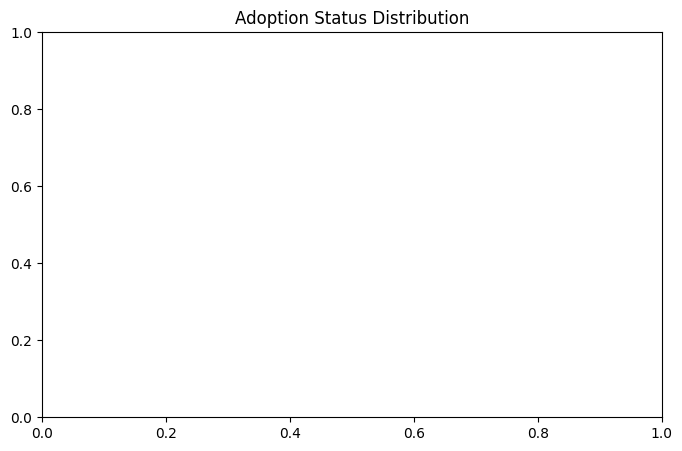

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Adoption_Status',
    data=df
)

plt.title("Adoption Status Distribution")

plt.show()

Correlation Heatmap

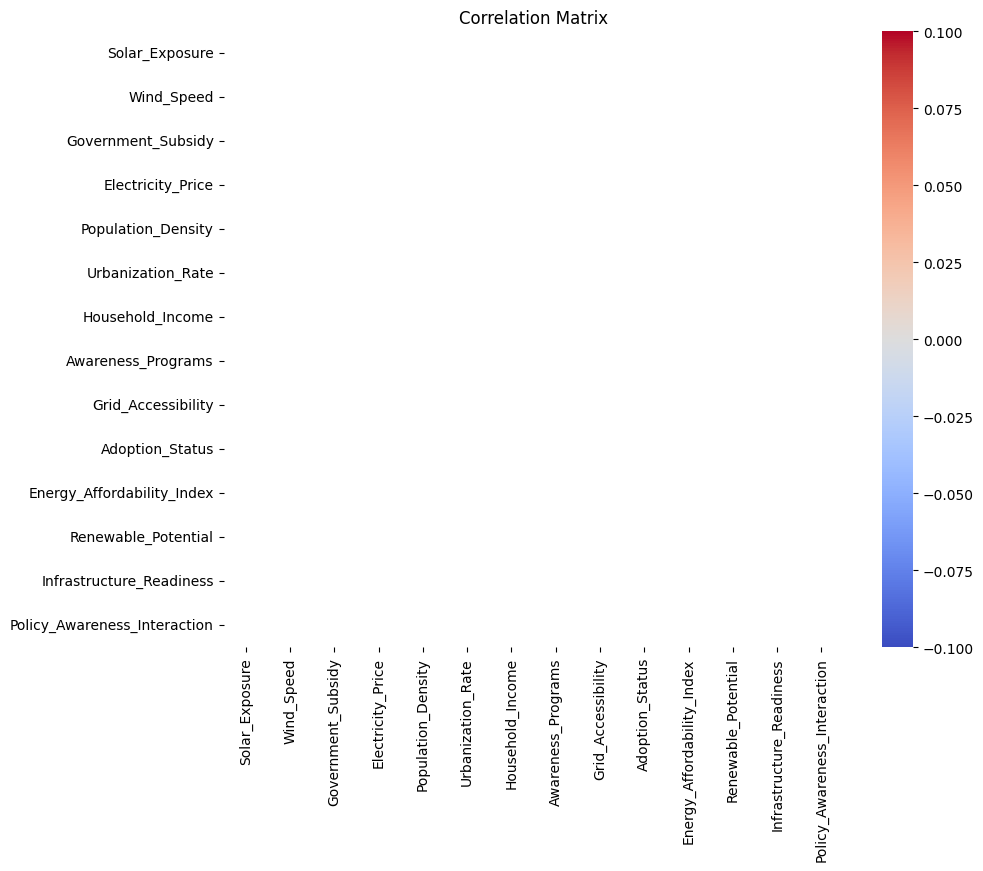

In [50]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

Encode Binary Variables

In [51]:
binary_cols = []

for col in binary_cols:

    df[col] = (
        df[col]
        .replace({
            "Yes":1,
            "No":0
        })
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

Encode Target Variable

In [56]:
label_encoder = LabelEncoder()

df["Adoption_Status"] = (
    label_encoder.fit_transform(
        df["Adoption_Status"]
    )
)

print(label_encoder.classes_)

[]


Feature Engineering

In [57]:
awareness_program_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Awareness_Programs'] = df['Awareness_Programs'].map(awareness_program_mapping)

grid_accessibility_mapping = {'Difficult': 0, 'Moderate': 1, 'Easy': 2}
df['Grid_Accessibility'] = df['Grid_Accessibility'].map(grid_accessibility_mapping)

df["Energy_Affordability_Index"] = (

    df["Household_Income"]

    /

    (df["Electricity_Price"] + 1)

)

df["Renewable_Potential"] = (

    df["Solar_Exposure"]

    +

    df["Wind_Speed"]

)

df["Infrastructure_Readiness"] = (

    df["Urbanization_Rate"]

    +

    df["Grid_Accessibility"]

)

df["Policy_Awareness_Interaction"] = (

    df["Government_Subsidy"]

    *

    df["Awareness_Programs"]

)

Final Missing Value Check

In [58]:
print(df.isnull().sum())

df = df.dropna()

print("Dataset Shape:")
print(df.shape)

Solar_Exposure                  0
Wind_Speed                      0
Government_Subsidy              0
Electricity_Price               0
Population_Density              0
Urbanization_Rate               0
Household_Income                0
Awareness_Programs              0
Grid_Accessibility              0
Adoption_Status                 0
Region_Suburban                 0
Region_Urban                    0
Energy_Affordability_Index      0
Renewable_Potential             0
Infrastructure_Readiness        0
Policy_Awareness_Interaction    0
dtype: int64
Dataset Shape:
(0, 16)


Split Features and Target

In [59]:
X = df.drop(
    "Adoption_Status",
    axis=1
)

y = df["Adoption_Status"]

Train-Test Split

In [65]:
# Reload the raw dataset to correctly get the 'Adoption_Status' for 'y'
raw_df_for_y = pd.read_csv("Renewable_Energy_Adoption.csv")

# Re-encode 'Adoption_Status' to ensure 'y' is consistent with X_scaled
# We use a new LabelEncoder here because the previous one might be corrupted by earlier re-runs
temp_label_encoder = LabelEncoder()
y = temp_label_encoder.fit_transform(raw_df_for_y["Adoption_Status"])
# Convert to Series for consistency with previous usage
y = pd.Series(y, name="Adoption_Status")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 15)
(200, 15)


Logistic Regression

In [66]:
lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

Decision Tree

In [67]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(X_test)

Random Forest

In [68]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

Support Vector Machine

In [69]:
svm = SVC(
    probability=True
)

svm.fit(
    X_train,
    y_train
)

svm_pred = svm.predict(X_test)

Evaluation Function

In [70]:
def evaluate_model(
        name,
        y_true,
        y_pred):

    return [

        name,

        accuracy_score(
            y_true,
            y_pred
        ),

        precision_score(
            y_true,
            y_pred,
            average='weighted'
        ),

        recall_score(
            y_true,
            y_pred,
            average='weighted'
        ),

        f1_score(
            y_true,
            y_pred,
            average='weighted'
        )
    ]

Compare Models

In [71]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "SVM",
        y_test,
        svm_pred
    )
)

results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.370,0.361335,0.370,0.361866
1,Decision Tree,0.305,0.306639,0.305,0.305518
0,Logistic Regression,0.285,0.277596,0.285,0.278876
3,SVM,0.265,0.262153,0.265,0.261636


Classification Report

In [72]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.38      0.36      0.37        64
           1       0.40      0.51      0.45        73
           2       0.29      0.22      0.25        63

    accuracy                           0.37       200
   macro avg       0.36      0.36      0.36       200
weighted avg       0.36      0.37      0.36       200



Hyperparameter Tuning

In [73]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,15,None],

    "min_samples_split":[2,5,10]

}

grid_search = GridSearchCV(

    RandomForestClassifier(
        random_state=42
    ),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)

Best Parameters:
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}


Best Model

In [74]:
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(
    X_test
)

accuracy_score(
    y_test,
    best_pred
)

0.36

Confusion Matrix

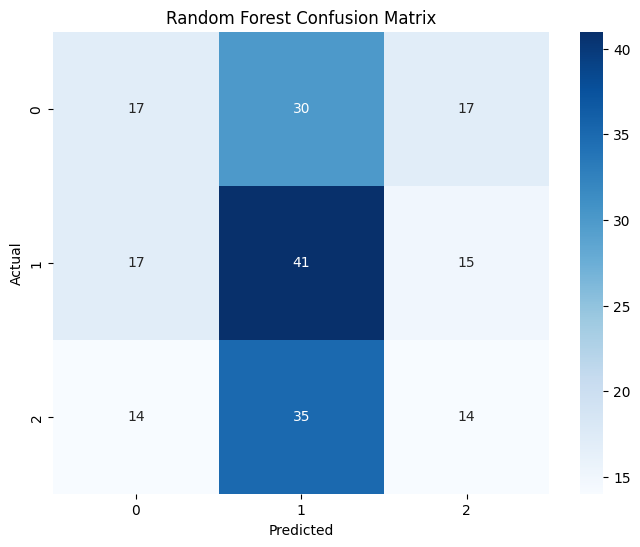

In [75]:
cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

Feature Importance

In [76]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":
    best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
3,Electricity_Price,0.098221
13,Infrastructure_Readiness,0.087527
12,Renewable_Potential,0.087394
0,Solar_Exposure,0.086548
4,Population_Density,0.086238
5,Urbanization_Rate,0.085781
11,Energy_Affordability_Index,0.084909
2,Government_Subsidy,0.083518
6,Household_Income,0.083190
1,Wind_Speed,0.081776


Feature Importance Plot

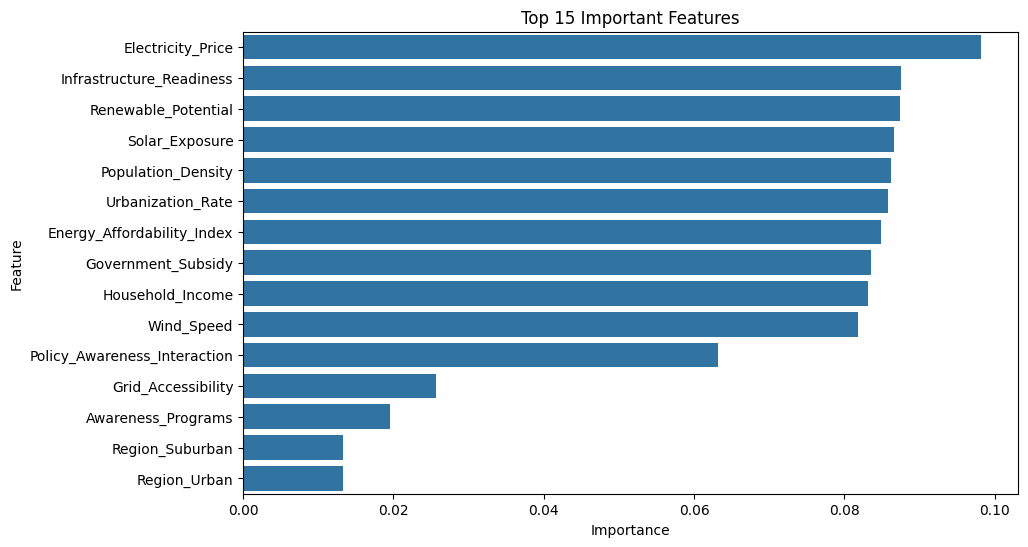

In [77]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title(
    "Top 15 Important Features"
)

plt.show()

Cross Validation

In [79]:
cv_scores = cross_val_score(

    best_rf,

    X_scaled,

    y,

    cv=5,

    scoring="accuracy"

)

print(
    "Cross Validation Accuracy:"
)

print(
    cv_scores.mean()
)

Cross Validation Accuracy:
0.345


Save Model

In [80]:
import joblib

joblib.dump(
    best_rf,
    "renewable_energy_model.pkl"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully
